In [3]:
# =====================================================
# AWD-LSTM (ULMFiT) - Setup
# =====================================================

from fastai.text.all import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import os

# -----------------------------------------------------
# Directories
# -----------------------------------------------------

MODEL_DIR = "awd_models"
RESULTS_DIR = "awd_results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Setup Complete")

Setup Complete


In [4]:
import datasets
import huggingface_hub

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

datasets: 3.6.0
huggingface_hub: 0.33.1


In [2]:
!pip uninstall -y datasets huggingface_hub
!pip install -q datasets==3.6.0 huggingface_hub==0.33.1

Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: huggingface_hub 1.18.0
Uninstalling huggingface_hub-1.18.0:
  Successfully uninstalled huggingface_hub-1.18.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.4/515.4 kB 41.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.38.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.33.1 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.33.1 which is incompatible.
transformers 5.10.2 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.33.1 which is incompatible.


In [ ]:
import os
os.kill(os.getpid(), 9)

In [5]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("imdb")

train_df = pd.DataFrame({
    "text": dataset["train"]["text"],
    "label": dataset["train"]["label"]
})

test_df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "label": dataset["test"]["label"]
})

print(train_df.shape)
print(test_df.shape)
train_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

(25000, 2)
(25000, 2)


,text,label
0,"I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered ""controversial"" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain politica...",0
1,"""I Am Curious: Yellow"" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity. Granted, they only offer some fleeting views, but where are the R-rated films with gaping vulvas and flapping labia? Nowhere, because they don't exist. The same goes for those crappy cable shows: schlongs swinging in the breeze but not a clitoris in sight. And those pretentious indie movies li...",0
2,"If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issues but it does so without any discernable motive. The viewer comes away with no new perspectives (unless one comes up with one while one's mind wanders, as it will invariably do during this pointless film).<br /><br />One might better spend one's time staring out a window at a tree growing.<br /><br />",0
3,"This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instead.<br /><br />The film has two strong elements and those are, (1) the realistic acting (2) the impressive, undeservedly good, photo. Apart from that, what strikes me most is the endless stream of silliness. Lena Nyman has to be most annoying actress in the world. She acts so stupid and with all the nudity in this film,...it's unattractive. Comparing to Godard's film, intellectuality has been replaced with stupidity. Without going too far on this subject, I would say that follows from the dif...",0
4,"Oh, brother...after hearing about this ridiculous film for umpteen years all I can think of is that old Peggy Lee song..<br /><br />""Is that all there is??"" ...I was just an early teen when this smoked fish hit the U.S. I was too young to get in the theater (although I did manage to sneak into ""Goodbye Columbus""). Then a screening at a local film museum beckoned - Finally I could see this film, except now I was as old as my parents were when they schlepped to see it!!<br /><br />The ONLY reason this film was not condemned to the anonymous sands of time was because of the obscenity case spa...",0


In [6]:
# =====================================================
# Create DataLoaders
# =====================================================

dls_lm = TextDataLoaders.from_df(
    train_df,
    text_col="text",
    is_lm=True,
    valid_pct=0.1,
    bs=64,
    seed=42
)

print("Language Model DataLoaders Created")

Language Model DataLoaders Created


In [7]:
# =====================================================
# Create AWD-LSTM Language Model
# =====================================================

learn_lm = language_model_learner(
    dls_lm,
    AWD_LSTM,
    drop_mult=0.3,
    metrics=[accuracy]
)

learn_lm.fine_tune(1)

print("Language Model Training Complete")

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:03&lt;00:00]</div>

epoch,train_loss,valid_loss,accuracy,time
0,4.156083,4.070603,0.287107,09:14


epoch,train_loss,valid_loss,accuracy,time
0,4.017553,3.972096,0.297085,11:01


Language Model Training Complete


In [8]:
# =====================================================
# Create Classification DataLoaders
# =====================================================

dls_clas = TextDataLoaders.from_df(
    train_df,
    valid_pct=0.1,
    seed=42,
    text_col="text",
    label_col="label",
    bs=64
)

print("Classification DataLoaders Created")

Classification DataLoaders Created


In [9]:
dls_clas.show_batch(max_n=2)

,text,category
0,"xxbos xxmaj match 1 : xxmaj tag xxmaj team xxmaj table xxmaj match xxmaj bubba xxmaj ray and xxmaj spike xxmaj dudley vs xxmaj eddie xxmaj guerrero and xxmaj chris xxmaj benoit xxmaj bubba xxmaj ray and xxmaj spike xxmaj dudley started things off with a xxmaj tag xxmaj team xxmaj table xxmaj match against xxmaj eddie xxmaj guerrero and xxmaj chris xxmaj benoit . xxmaj according to the rules of the match , both opponents have to go through tables in order to get the win . xxmaj benoit and xxmaj guerrero heated up early on by taking turns hammering first xxmaj spike and then xxmaj bubba xxmaj ray . a xxmaj german suplex by xxmaj benoit to xxmaj bubba took the wind out of the xxmaj dudley brother . xxmaj spike tried to help his brother , but the referee restrained him while xxmaj benoit and xxmaj guerrero",1
1,"xxbos * ! ! - xxup spoilers - ! ! * \n\n xxmaj before i begin this , let me say that i have had both the advantages of seeing this movie on the big screen and of having seen the "" authorized xxmaj version "" of this movie , remade by xxmaj stephen xxmaj king , himself , in 1997 . \n\n xxmaj both advantages made me appreciate this version of "" the xxmaj shining , "" all the more . \n\n xxmaj also , let me say that xxmaj i 've read xxmaj mr . xxmaj king 's book , "" the xxmaj shining "" on many occasions over the years , and while i love the book and am a huge fan of his work , xxmaj stanley xxmaj kubrick 's retelling of this story is far more compelling … and xxup scary . \n\n xxmaj kubrick",1


In [10]:
# Save encoder from language model
learn_lm.save_encoder("imdb_encoder")

# Create classifier
learn_clas = text_classifier_learner(
    dls_clas,
    AWD_LSTM,
    drop_mult=0.5,
    metrics=[accuracy]
)

# Load encoder
learn_clas.load_encoder("imdb_encoder")

print("Classifier Created Successfully")

Classifier Created Successfully


In [11]:
# =====================================================
# Train AWD-LSTM Classifier
# =====================================================

learn_clas.fine_tune(1)

epoch,train_loss,valid_loss,accuracy,time
0,0.397444,0.336674,0.853600,01:55


epoch,train_loss,valid_loss,accuracy,time
0,0.323744,0.268426,0.887200,05:13


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

preds, targets = learn_clas.get_preds()

pred_labels = preds.argmax(dim=1).numpy()
true_labels = targets.numpy()

acc = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels)
recall = recall_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.8872
Precision : 0.8586
Recall    : 0.9205
F1 Score  : 0.8884


In [13]:
learn_clas.export("awd_lstm_classifier.pkl")

print("AWD-LSTM Model Saved")

AWD-LSTM Model Saved


In [14]:
results_df = pd.DataFrame({
    "Model": ["AWD-LSTM"],
    "Accuracy": [acc],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1]
})

results_df.to_csv(
    "awd_lstm_metrics.csv",
    index=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,AWD-LSTM,0.8872,0.858563,0.920492,0.888449


In [15]:
comparison_df = pd.DataFrame({
    "Model": ["Custom LSTM", "AWD-LSTM"],
    "Accuracy": [0.8512, 0.8948],
    "Precision": [0.864074, 0.881883],
    "Recall": [0.833520, 0.905738],
    "F1 Score": [0.848522, 0.893651]
})

comparison_df.to_csv(
    "model_comparison.csv",
    index=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Custom LSTM,0.8512,0.864074,0.833520,0.848522
1,AWD-LSTM,0.8948,0.881883,0.905738,0.893651


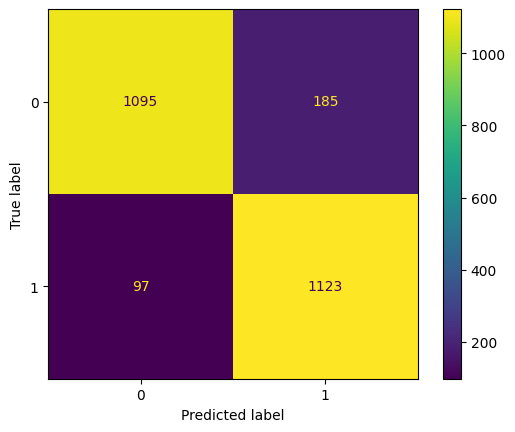

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.savefig(
    "awd_lstm_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [17]:
report = classification_report(
    true_labels,
    pred_labels
)

with open(
    "awd_lstm_classification_report.txt",
    "w"
) as f:
    f.write(report)

print(report)

              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1280
           1       0.86      0.92      0.89      1220

    accuracy                           0.89      2500
   macro avg       0.89      0.89      0.89      2500
weighted avg       0.89      0.89      0.89      2500



In [18]:
with open(
    "awd-lstm_classification_report.txt",
    "w"
) as f:
    f.write(report)

print("Classification Report Saved")

Classification Report Saved


In [22]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".pkl") or file.endswith(".pth"):
            print(os.path.join(root, file))

/content/awd_lstm_classifier.pkl
/content/drive/MyDrive/project-main/assets/pretrained_v2/f0G40k.pth
/content/drive/MyDrive/project-main/assets/pretrained_v2/G40k.pth
/content/drive/MyDrive/project-main/assets/pretrained_v2/f0D40k.pth
/content/drive/MyDrive/project-main/assets/pretrained_v2/D40k.pth
/content/models/imdb_encoder.pth


In [23]:
from fastai.text.all import *

learn = load_learner('/content/awd_lstm_classifier.pkl')

print("Model Loaded Successfully")

Model Loaded Successfully


In [24]:
learn.predict(
    "This movie was absolutely amazing and I loved every second of it."
)

('1', tensor(1), tensor([9.4886e-04, 9.9905e-01]))